# 03 — Customer lifecycle: new vs existing, repeat, cohorts

Answers questions **4–6** using the **same** preparation as notebooks 01 and 02.
SQL Server Raw stays the source of truth. No Silver/Gold tables.
This notebook starts from a **fresh kernel** (it reloads from SQL).

Lifecycle labels use **first observed** purchases in this extract, not confirmed first-ever purchases.

## 0. Setup and reload Raw (SELECT only)

In [1]:
from datetime import datetime
from decimal import Decimal, ROUND_HALF_UP
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc

PROJECT = Path("..").resolve()
if not (PROJECT / "scripts").exists():
    PROJECT = Path(".").resolve()
TABLES = PROJECT / "outputs" / "tables"
FIGURES = PROJECT / "outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)


def unique_output_path(path: Path) -> Path:
    """If the target exists, write a timestamped file instead of overwriting."""
    if not path.exists():
        return path
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")


server = r".\MSSQLSERVER02"
database = "RetailAnalytics"
driver = "ODBC Driver 18 for SQL Server"
connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

read_sql = """
SELECT
    raw_row_id, InvoiceNo, StockCode, Description, Quantity,
    InvoiceDate, UnitPrice, CustomerID, Country, source_file, loaded_at
FROM raw.online_retail;
"""

connection = pyodbc.connect(connection_string)
try:
    df_raw = pd.read_sql(read_sql, connection)
finally:
    connection.close()

df = df_raw.copy()
EXPECTED_ROWS = 541_909
assert len(df) == EXPECTED_ROWS
print("Loaded", len(df), "rows")

C:\Users\Admin\AppData\Local\Temp\ipykernel_9844\1915933047.py:47: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(read_sql, connection)


Loaded 541909 rows


## 1. Same preparation as notebooks 01 and 02

Types, StockCode map, duplicate extras (kept in the baseline), and the identified-customer positive merchandise-sale mask.

In [2]:
def penny(x) -> Decimal:
    return Decimal(str(float(x))).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)


def penny_sum(series: pd.Series) -> Decimal:
    return penny(float(series.sum())) if len(series) else Decimal("0.00")


for col in ["InvoiceNo", "StockCode", "CustomerID", "Country"]:
    df[col] = df[col].astype("string")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
desc = df["Description"].astype("string").str.strip()
df["Description_clean"] = desc.mask(desc.eq(""), pd.NA)
df["UnitPrice"] = df["UnitPrice"].astype("float64")
df["line_value"] = df["Quantity"] * df["UnitPrice"]

df["is_c_prefix_invoice"] = df["InvoiceNo"].str.upper().str.startswith("C", na=False)

# Same explicit map as notebook 01 (executed counts: postage 2110, manual 571).
STOCKCODE_GROUP = {
    "POST": "postage_carriage",
    "DOT": "postage_carriage",
    "C2": "postage_carriage",
    "AMAZONFEE": "fees_commission",
    "CRUK": "fees_commission",
    "BANK CHARGES": "fees_commission",
    "D": "discount",
    "M": "manual_unresolved",
    "S": "samples",
    "B": "bad_debt_adjustment",
}
df["code_group"] = df["StockCode"].map(STOCKCODE_GROUP).astype("string")
df["code_group"] = df["code_group"].fillna("merchandise_candidate")
adjust_bad_debt = df["Description"].astype("string").str.contains(
    "Adjust bad debt", case=False, na=False
)
df.loc[adjust_bad_debt, "code_group"] = "bad_debt_adjustment"

print("code_group counts (notebook 01 mapping, not rewritten):")
print(df["code_group"].value_counts())

code_group counts (notebook 01 mapping, not rewritten):
code_group
merchandise_candidate    538998
postage_carriage           2110
manual_unresolved           571
fees_commission              87
discount                     77
samples                      63
bad_debt_adjustment           3
Name: count, dtype: Int64


In [3]:
BUSINESS_COLS = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country",
]
g = df.groupby(BUSINESS_COLS, dropna=False, sort=False)
df["duplicate_group_size"] = g["raw_row_id"].transform("size")
# Unique raw_row_id: rank first keeps the lowest id as the non-extra row.
df["duplicate_row_number"] = g["raw_row_id"].rank(method="first")
df["is_duplicate_extra"] = (df["duplicate_group_size"] > 1) & (df["duplicate_row_number"] > 1)

df["invoice_month"] = df["InvoiceDate"].dt.to_period("M")
observation_end = df["InvoiceDate"].max()  # full raw extract, not purchase-only
partial_month = observation_end.to_period("M")
last_full_month = partial_month - 1

is_merch = df["code_group"] == "merchandise_candidate"
mask_sale = (
    is_merch & (df["Quantity"] > 0) & (df["UnitPrice"] > 0) & ~df["is_c_prefix_invoice"]
)
mask_id_purchase = mask_sale & df["CustomerID"].notna()

NB01_ID_GROSS = Decimal("8761066.65")
assert penny_sum(df.loc[mask_id_purchase, "line_value"]) == NB01_ID_GROSS
assert len(df) == EXPECTED_ROWS
print("Identified-customer gross purchases:", NB01_ID_GROSS)
print("Observation end (full extract):", observation_end)
print("Partial month:", partial_month, "| last full month:", last_full_month)

Identified-customer gross purchases: 8761066.65
Observation end (full extract): 2011-12-09 12:50:00
Partial month: 2011-12 | last full month: 2011-11


## 2. Purchase-level data

One row per identified `CustomerID` + `InvoiceNo` on the **positive merchandise-sale** mask.
Duplicate extras stay in the baseline. Frequency uses distinct invoices, not line counts.

`purchase_timestamp` is the earliest eligible `InvoiceDate` on that invoice.

In [4]:
eligible = df.loc[mask_id_purchase].copy()

purchases = (
    eligible.groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        purchase_timestamp=("InvoiceDate", "min"),
        gross_purchase_value=("line_value", "sum"),
        positive_units=("Quantity", "sum"),
    )
)
purchases["purchase_month"] = purchases["purchase_timestamp"].dt.to_period("M")

assert purchases.duplicated(["CustomerID", "InvoiceNo"]).sum() == 0
assert penny_sum(purchases["gross_purchase_value"]) == NB01_ID_GROSS

# Deterministic order: timestamp, then InvoiceNo (if two invoices share the earliest time,
# the lower InvoiceNo is treated as first; the other can count as a same-timestamp repeat).
purchases = purchases.sort_values(
    ["CustomerID", "purchase_timestamp", "InvoiceNo"]
).reset_index(drop=True)

customers = (
    purchases.groupby("CustomerID", as_index=False)
    .agg(
        first_observed_purchase_timestamp=("purchase_timestamp", "min"),
        distinct_purchase_invoices=("InvoiceNo", "nunique"),
    )
)
customers["first_observed_purchase_month"] = customers[
    "first_observed_purchase_timestamp"
].dt.to_period("M")

first_invoice = (
    purchases.groupby("CustomerID", as_index=False)
    .head(1)[["CustomerID", "InvoiceNo", "purchase_timestamp"]]
    .rename(columns={"InvoiceNo": "first_invoice_no", "purchase_timestamp": "first_invoice_ts"})
)
customers = customers.merge(first_invoice, on="CustomerID", how="left")
assert len(customers) == purchases["CustomerID"].nunique()

print("Purchase invoices:", len(purchases))
print("Identified purchasing customers:", len(customers))
print(purchases.head(3).to_string(index=False))

Purchase invoices: 18402
Identified purchasing customers: 4334
CustomerID InvoiceNo  purchase_timestamp  gross_purchase_value  positive_units purchase_month
     12346    541431 2011-01-18 10:01:00              77183.60           74215        2011-01
     12347    537626 2010-12-07 14:57:00                711.79             319        2010-12
     12347    542237 2011-01-26 14:30:00                475.39             315        2011-01


## 3. Question 4 — New versus existing customer revenue

In a customer’s **first observed purchase month**, every purchase that month is **new**.
Later months for that customer are **existing**.

This is first-observed status in the extract. The December 2010 cohort may include customers who bought before 2010-12-01.

In [5]:
purchases = purchases.merge(
    customers[["CustomerID", "first_observed_purchase_month"]],
    on="CustomerID",
    how="left",
)
purchases["lifecycle"] = np.where(
    purchases["purchase_month"] == purchases["first_observed_purchase_month"],
    "new",
    "existing",
)

# One lifecycle group per customer-month.
customer_month = (
    purchases.groupby(["CustomerID", "purchase_month", "lifecycle"], as_index=False)
    .agg(gross_merchandise_sales=("gross_purchase_value", "sum"))
)
n_status = customer_month.groupby(["CustomerID", "purchase_month"])["lifecycle"].nunique()
assert (n_status == 1).all()

monthly_life = (
    customer_month.groupby(["purchase_month", "lifecycle"], as_index=False)
    .agg(
        gross_merchandise_sales=("gross_merchandise_sales", "sum"),
        distinct_customers=("CustomerID", "nunique"),
    )
)

new_m = monthly_life.loc[monthly_life["lifecycle"] == "new"].set_index("purchase_month")
exist_m = monthly_life.loc[monthly_life["lifecycle"] == "existing"].set_index("purchase_month")
all_months = new_m.index.union(exist_m.index).sort_values()

life_out = pd.DataFrame({"month": all_months.astype(str)})
life_out = life_out.set_index(all_months)
life_out["new_customer_gross_sales"] = new_m["gross_merchandise_sales"].reindex(all_months, fill_value=0.0)
life_out["existing_customer_gross_sales"] = exist_m["gross_merchandise_sales"].reindex(
    all_months, fill_value=0.0
)
life_out["total_identified_gross_sales"] = (
    life_out["new_customer_gross_sales"] + life_out["existing_customer_gross_sales"]
)
den = life_out["total_identified_gross_sales"].replace(0, pd.NA)
life_out["new_revenue_share_pct"] = life_out["new_customer_gross_sales"] / den * 100
life_out["existing_revenue_share_pct"] = life_out["existing_customer_gross_sales"] / den * 100
life_out["distinct_new_customers"] = (
    new_m["distinct_customers"].reindex(all_months, fill_value=0).astype(int)
)
life_out["distinct_existing_customers"] = (
    exist_m["distinct_customers"].reindex(all_months, fill_value=0).astype(int)
)
life_out["is_partial_final_month"] = life_out.index == partial_month
life_out = life_out.reset_index(drop=True)

assert penny_sum(life_out["total_identified_gross_sales"]) == NB01_ID_GROSS
month_sum_ok = (
    life_out["new_customer_gross_sales"] + life_out["existing_customer_gross_sales"]
    - life_out["total_identified_gross_sales"]
).abs().max() < 1e-6
assert month_sum_ok

print(life_out.to_string(index=False))

  month  new_customer_gross_sales  existing_customer_gross_sales  total_identified_gross_sales  new_revenue_share_pct  existing_revenue_share_pct  distinct_new_customers  distinct_existing_customers  is_partial_final_month
2010-12                567490.720                           0.00                    567490.720             100.000000                    0.000000                     884                            0                   False
2011-01                289873.800                      274152.84                    564026.640              51.393636                   48.606364                     416                          323                   False
2011-02                157691.530                      285654.49                    443346.020              35.568500                   64.431500                     380                          377                   False
2011-03                197217.120                      387345.73                    584562.850              

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\new_existing_monthly.png


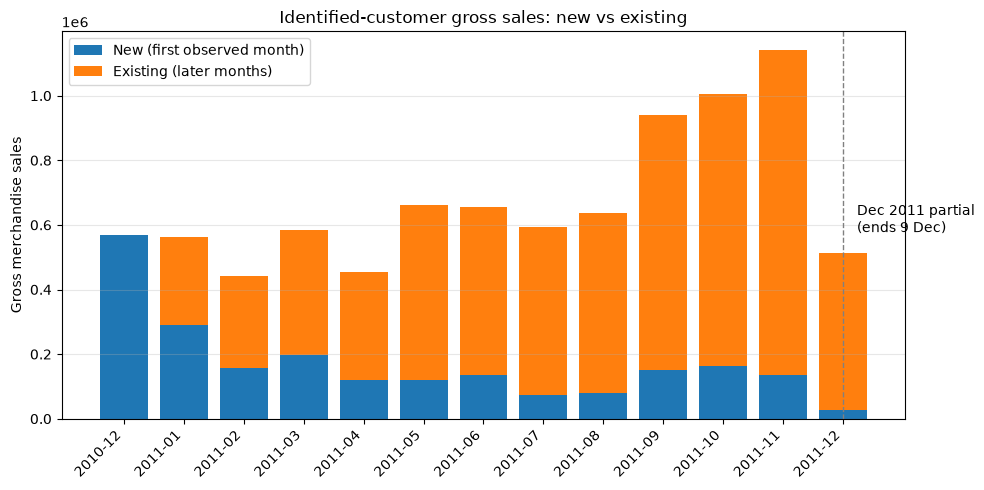

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(life_out))
ax.bar(x, life_out["new_customer_gross_sales"], label="New (first observed month)")
ax.bar(
    x,
    life_out["existing_customer_gross_sales"],
    bottom=life_out["new_customer_gross_sales"],
    label="Existing (later months)",
)
ax.set_xticks(x, life_out["month"], rotation=45, ha="right")
ax.set_ylabel("Gross merchandise sales")
ax.set_title("Identified-customer gross sales: new vs existing")
ax.legend()
partial_idx = life_out.index[life_out["is_partial_final_month"]]
if len(partial_idx):
    i = int(partial_idx[0])
    ax.axvline(i, color="gray", linestyle="--", linewidth=1)
    ax.annotate(
        "Dec 2011 partial\n(ends 9 Dec)",
        xy=(i, float(life_out.loc[i, "total_identified_gross_sales"])),
        xytext=(10, 15),
        textcoords="offset points",
    )
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
q4_fig = unique_output_path(FIGURES / "new_existing_monthly.png")
fig.savefig(q4_fig, dpi=120)
print("Saved", q4_fig)
plt.show()

## 4. Question 5 — Repeat purchase rate

**A.** Observed-window: share of purchasing customers with at least two distinct invoices in the extract.

**B.** 90-day: only customers whose first observed purchase plus 90 days is on or before the extract’s last `InvoiceDate`.
A repeat is a **second distinct invoice** with timestamp ≤ first purchase + 90 days (exact 90-day cutoff included).

If two invoices share the earliest timestamp, `InvoiceNo` order picks the first; the other may count as a same-timestamp repeat.

In [7]:
n_customers = len(customers)
n_repeat_window = int((customers["distinct_purchase_invoices"] >= 2).sum())
observed_rate = n_repeat_window / n_customers if n_customers else float("nan")

print("A. Observed-window repeat")
print("  numerator:", n_repeat_window)
print("  denominator:", n_customers)
print("  rate:", observed_rate)

horizon = pd.Timedelta(days=90)
customers["followup_ok"] = (
    customers["first_observed_purchase_timestamp"] + horizon <= observation_end
)

p90 = purchases.merge(
    customers[["CustomerID", "first_invoice_no", "first_observed_purchase_timestamp", "followup_ok"]],
    on="CustomerID",
    how="left",
)
p90["is_repeat_within_90d"] = (
    (p90["InvoiceNo"] != p90["first_invoice_no"])
    & (p90["purchase_timestamp"] <= p90["first_observed_purchase_timestamp"] + horizon)
)
repeated_90 = set(p90.loc[p90["is_repeat_within_90d"], "CustomerID"])
eligible_90 = customers.loc[customers["followup_ok"]].copy()
eligible_90["repeated_within_90d"] = eligible_90["CustomerID"].isin(repeated_90)

n_eligible = int(eligible_90["followup_ok"].sum()) if len(eligible_90) else 0
n_repeated_90 = int(eligible_90["repeated_within_90d"].sum())
n_excluded_90 = n_customers - n_eligible
rate_90 = n_repeated_90 / n_eligible if n_eligible else float("nan")

assert n_repeat_window <= n_customers
assert n_repeated_90 <= n_eligible
assert (
    customers.loc[customers["followup_ok"], "first_observed_purchase_timestamp"] + horizon
    <= observation_end
).all()

print("B. 90-day repeat")
print("  numerator:", n_repeated_90)
print("  denominator (eligible):", n_eligible)
print("  rate:", rate_90)
print("  excluded (insufficient follow-up):", n_excluded_90)

repeat_summary = pd.DataFrame(
    [
        {
            "measure": "observed_window",
            "numerator": n_repeat_window,
            "denominator": n_customers,
            "rate": observed_rate,
            "customers_excluded_insufficient_followup": 0,
            "note": "At least two distinct purchase invoices in the extract.",
        },
        {
            "measure": "repeat_90d",
            "numerator": n_repeated_90,
            "denominator": n_eligible,
            "rate": rate_90,
            "customers_excluded_insufficient_followup": n_excluded_90,
            "note": "Second distinct invoice at or before first purchase + 90 days; eligible if first+90d <= observation_end.",
        },
    ]
)
print(repeat_summary.to_string(index=False))

A. Observed-window repeat
  numerator: 2829
  denominator: 4334
  rate: 0.6527457314259345
B. 90-day repeat
  numerator: 1593
  denominator (eligible): 3368
  rate: 0.4729809976247031
  excluded (insufficient follow-up): 966
        measure  numerator  denominator     rate  customers_excluded_insufficient_followup                                                                                                     note
observed_window       2829         4334 0.652746                                         0                                                  At least two distinct purchase invoices in the extract.
     repeat_90d       1593         3368 0.472981                                       966 Second distinct invoice at or before first purchase + 90 days; eligible if first+90d <= observation_end.


cohort_month  eligible_customers  repeated_within_90d     rate
     2010-12                 884                  526 0.595023
     2011-01                 416                  202 0.485577
     2011-02                 380                  165 0.434211
     2011-03                 452                  188 0.415929
     2011-04                 300                  123 0.410000
     2011-05                 284                  108 0.380282
     2011-06                 242                   94 0.388430
     2011-07                 187                   80 0.427807
     2011-08                 169                   77 0.455621
     2011-09                  54                   30 0.555556


Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\repeat_90d_by_cohort.png


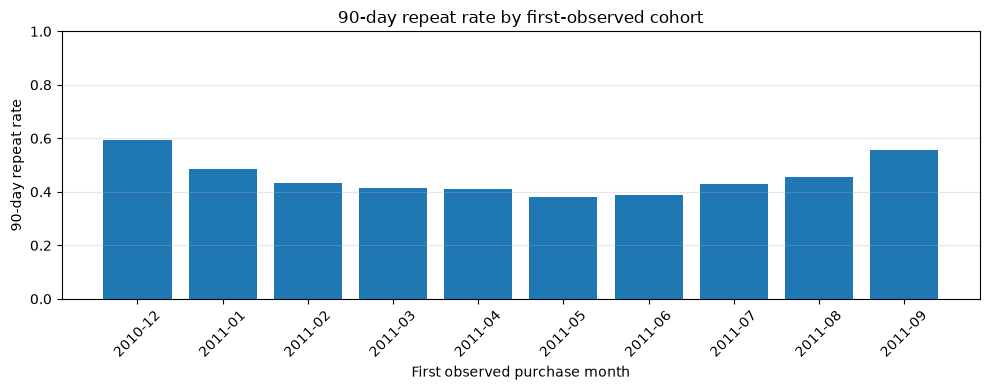

In [8]:
repeat_90_cohort = (
    eligible_90.groupby("first_observed_purchase_month", dropna=False)
    .agg(
        eligible_customers=("CustomerID", "nunique"),
        repeated_within_90d=("repeated_within_90d", "sum"),
    )
    .reset_index()
    .rename(columns={"first_observed_purchase_month": "cohort_month"})
)
repeat_90_cohort["rate"] = (
    repeat_90_cohort["repeated_within_90d"] / repeat_90_cohort["eligible_customers"]
)
repeat_90_cohort["cohort_month"] = repeat_90_cohort["cohort_month"].astype(str)
repeat_90_cohort = repeat_90_cohort.sort_values("cohort_month")
print(repeat_90_cohort.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(repeat_90_cohort["cohort_month"], repeat_90_cohort["rate"])
ax.set_ylim(0, 1)
ax.set_ylabel("90-day repeat rate")
ax.set_xlabel("First observed purchase month")
ax.set_title("90-day repeat rate by first-observed cohort")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
q5_fig = unique_output_path(FIGURES / "repeat_90d_by_cohort.png")
fig.savefig(q5_fig, dpi=120)
print("Saved", q5_fig)
plt.show()

## 5. Question 6 — Monthly cohort retention (repeat activity)

Cohort = first observed purchase calendar month.
A customer is **active** in a month if they have at least one positive purchase invoice that month.

This is **monthly repeat activity**, not confirmed permanent churn. Customers may skip a month and return.

The main heatmap drops **December 2011 activity** (partial month) and the **December 2011 acquisition cohort**.
Those rows remain in the detailed CSV output.

Unobservable future months are missing, not zero. Fully observed months with no activity are zero.

In [9]:
activity = (
    purchases[["CustomerID", "purchase_month"]]
    .drop_duplicates()
    .merge(
        customers[["CustomerID", "first_observed_purchase_month"]],
        on="CustomerID",
        how="left",
    )
)
activity["cohort_year"] = activity["first_observed_purchase_month"].dt.year
activity["cohort_month_num"] = activity["first_observed_purchase_month"].dt.month
activity["activity_year"] = activity["purchase_month"].dt.year
activity["activity_month_num"] = activity["purchase_month"].dt.month
activity["month_offset"] = (
    12 * (activity["activity_year"] - activity["cohort_year"])
    + (activity["activity_month_num"] - activity["cohort_month_num"])
)

cohort_sizes = (
    customers.groupby("first_observed_purchase_month", dropna=False)["CustomerID"]
    .nunique()
    .rename("cohort_size")
)

# Detailed matrices include December 2011.
count_long = (
    activity.groupby(["first_observed_purchase_month", "month_offset"], dropna=False)[
        "CustomerID"
    ]
    .nunique()
    .rename("active_customers")
    .reset_index()
)
count_long = count_long.merge(
    cohort_sizes.reset_index(),
    on="first_observed_purchase_month",
    how="left",
)

# Fill zeros for fully observed offsets; leave later offsets missing.
# Observation for detailed table: last extract month (Dec 2011) is present as activity
# but is partial. Heatmap uses last_full_month only.
def observable_max_offset(cohort_period, last_month):
    return (
        12 * (last_month.year - cohort_period.year)
        + (last_month.month - cohort_period.month)
    )


def complete_grid(last_month, include_cohorts):
    rows = []
    for cohort in include_cohorts:
        size = int(cohort_sizes.loc[cohort])
        max_off = observable_max_offset(cohort, last_month)
        sub = count_long.loc[
            count_long["first_observed_purchase_month"] == cohort,
            ["month_offset", "active_customers"],
        ].set_index("month_offset")["active_customers"]
        for off in range(0, max_off + 1):
            active = int(sub.loc[off]) if off in sub.index else 0
            rows.append(
                {
                    "cohort_month": str(cohort),
                    "month_offset": off,
                    "active_customers": active,
                    "cohort_size": size,
                    "retention_rate": active / size if size else pd.NA,
                }
            )
        # Offsets beyond last_month stay off the grid (missing, not zero).
    return pd.DataFrame(rows)


all_cohorts = cohort_sizes.index.sort_values()
detailed_grid = complete_grid(partial_month, all_cohorts)

count_wide = detailed_grid.pivot_table(
    index="cohort_month",
    columns="month_offset",
    values="active_customers",
    aggfunc="sum",
)
retention_wide = detailed_grid.pivot_table(
    index="cohort_month",
    columns="month_offset",
    values="retention_rate",
    aggfunc="sum",
)

print("Cohort sizes:")
print(cohort_sizes.to_string())
print("\nDetailed active-customer counts (including Dec 2011):")
print(count_wide.to_string())

Cohort sizes:
first_observed_purchase_month
2010-12    884
2011-01    416
2011-02    380
2011-03    452
2011-04    300
2011-05    284
2011-06    242
2011-07    187
2011-08    169
2011-09    299
2011-10    357
2011-11    323
2011-12     41
Freq: M

Detailed active-customer counts (including Dec 2011):
month_offset     0      1      2      3      4      5      6      7      8      9      10     11     12
cohort_month                                                                                           
2010-12       884.0  323.0  286.0  339.0  320.0  352.0  320.0  308.0  312.0  349.0  330.0  444.0  234.0
2011-01       416.0   91.0  111.0   95.0  132.0  120.0  103.0  100.0  123.0  136.0  152.0   49.0    NaN
2011-02       380.0   71.0   71.0  109.0  103.0   93.0   97.0  104.0   94.0  116.0   26.0    NaN    NaN
2011-03       452.0   67.0  114.0   90.0  101.0   76.0  121.0  104.0  126.0   39.0    NaN    NaN    NaN
2011-04       300.0   63.0   61.0   63.0   59.0   68.0   65.0   78.0   22.

Month-0 heatmap retention (should be 1.0):
count    12.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: retention_rate, dtype: float64


Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\cohort_retention_heatmap.png


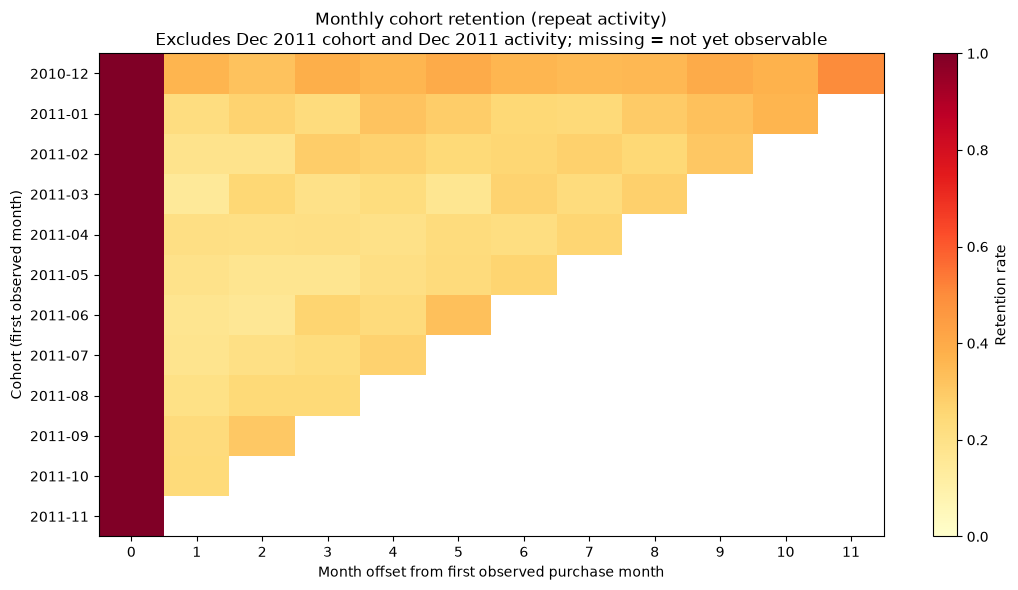

In [10]:
# Main heatmap: no Dec 2011 cohort; no Dec 2011 activity (use last full month as horizon).
heatmap_cohorts = [c for c in all_cohorts if c != partial_month]
heatmap_grid = complete_grid(last_full_month, heatmap_cohorts)

heat_counts = heatmap_grid.pivot_table(
    index="cohort_month",
    columns="month_offset",
    values="active_customers",
    aggfunc="sum",
)
heat_ret = heatmap_grid.pivot_table(
    index="cohort_month",
    columns="month_offset",
    values="retention_rate",
    aggfunc="sum",
)

# Validation on detailed + heatmap grids
assert (detailed_grid["active_customers"] <= detailed_grid["cohort_size"]).all()
assert detailed_grid["retention_rate"].between(0, 1).all()
assert (heatmap_grid["retention_rate"].between(0, 1)).all()
m0 = heatmap_grid.loc[heatmap_grid["month_offset"] == 0, "retention_rate"]
assert (m0.sub(1.0).abs() < 1e-12).all()
# Unobservable future cells are absent from the grid (missing, not zero).
print("Month-0 heatmap retention (should be 1.0):")
print(m0.describe())

fig, ax = plt.subplots(figsize=(11, 6))
arr = heat_ret.to_numpy(dtype=float)
masked = np.ma.masked_invalid(arr)
im = ax.imshow(masked, aspect="auto", vmin=0, vmax=1, cmap="YlOrRd")
ax.set_xticks(range(arr.shape[1]), heat_ret.columns.astype(int))
ax.set_yticks(range(arr.shape[0]), heat_ret.index.astype(str))
ax.set_xlabel("Month offset from first observed purchase month")
ax.set_ylabel("Cohort (first observed month)")
ax.set_title(
    "Monthly cohort retention (repeat activity)\n"
    "Excludes Dec 2011 cohort and Dec 2011 activity; missing = not yet observable"
)
fig.colorbar(im, ax=ax, label="Retention rate")
fig.tight_layout()
q6_fig = unique_output_path(FIGURES / "cohort_retention_heatmap.png")
fig.savefig(q6_fig, dpi=120)
print("Saved", q6_fig)
plt.show()

## 6. Validation (assertions)

In [11]:
assert purchases.duplicated(["CustomerID", "InvoiceNo"]).sum() == 0
assert penny_sum(purchases["gross_purchase_value"]) == NB01_ID_GROSS
assert penny_sum(life_out["total_identified_gross_sales"]) == NB01_ID_GROSS
assert (
    (
        life_out["new_customer_gross_sales"] + life_out["existing_customer_gross_sales"]
        - life_out["total_identified_gross_sales"]
    ).abs()
    < 1e-6
).all()
assert (n_status == 1).all()
assert n_repeat_window <= n_customers
assert n_repeated_90 <= n_eligible
assert (
    customers.loc[customers["followup_ok"], "first_observed_purchase_timestamp"] + horizon
    <= observation_end
).all()
assert (detailed_grid["active_customers"] <= detailed_grid["cohort_size"]).all()
assert detailed_grid["retention_rate"].between(0, 1).all()
assert (heatmap_grid.loc[heatmap_grid["month_offset"] == 0, "retention_rate"] == 1.0).all()

# Future offsets (beyond each cohort's last extract month) must not appear as zeros.
for cohort in all_cohorts:
    max_off = observable_max_offset(cohort, partial_month)
    offs = detailed_grid.loc[
        detailed_grid["cohort_month"] == str(cohort), "month_offset"
    ]
    assert offs.max() == max_off
    assert set(offs) == set(range(0, max_off + 1))

print("All lifecycle, repeat, and cohort assertions passed.")

All lifecycle, repeat, and cohort assertions passed.


## 7. Save summary tables (non-overwriting)

In [12]:
life_path = unique_output_path(TABLES / "new_existing_monthly.csv")
repeat_path = unique_output_path(TABLES / "repeat_purchase_summary.csv")
repeat_c_path = unique_output_path(TABLES / "repeat_90d_by_cohort.csv")
counts_path = unique_output_path(TABLES / "cohort_customer_counts.csv")
ret_path = unique_output_path(TABLES / "cohort_retention.csv")

life_out.to_csv(life_path, index=False)
repeat_summary.to_csv(repeat_path, index=False)
repeat_90_cohort.to_csv(repeat_c_path, index=False)
count_wide.to_csv(counts_path)
retention_wide.to_csv(ret_path)

print("Saved", life_path)
print("Saved", repeat_path)
print("Saved", repeat_c_path)
print("Saved", counts_path)
print("Saved", ret_path)

Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\new_existing_monthly.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\repeat_purchase_summary.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\repeat_90d_by_cohort.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\cohort_customer_counts.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\cohort_retention.csv


## 8. Findings

Figures are from this executed notebook. Identified-customer gross merchandise sales reconcile to **8,761,066.65**. Duplicate extras remain in the baseline. Labels use **first observed** purchases in this extract.

**Repeat purchase rate** is about distinct invoices (how many customers buy more than once, or again within 90 days). **Monthly cohort retention** is about calendar-month activity (whether a first-observed cohort has at least one purchase invoice in a later month). An inactive month is not confirmed permanent churn.

### Question 4 — New versus existing customer revenue

- **2010-12** is entirely new-customer gross (**567,490.72**, **884** first-observed customers, **100%** new share). There are no existing customers in the first extract month.
- Existing-customer gross first exceeds new-customer gross in **2011-02** (**285,654.49** vs **157,691.53**; existing share **64.43%**). In complete **2011-11**, existing customers account for **1,007,089.44** of **1,142,145.77** identified gross (**88.18%**); **1,337** existing vs **323** new customers.
- **2011-12** is partial (ends 2011-12-09): identified gross **513,230.43**, new share **5.20%** (**41** new customers). That month is not a full-month new/existing mix.

### Question 5 — Repeat purchase rate

- Observed-window: **2,829 / 4,334** purchasing customers have at least two distinct invoices (**65.27%**).
- 90-day: **1,593 / 3,368** eligible customers repeat by first purchase + 90 days (**47.30%**). **966** customers are excluded because first purchase + 90 days is after observation end **2011-12-09 12:50:00**.
- By first-observed cohort, 90-day rates among eligible customers range from **38.03%** (**2011-05**: **108 / 284**) to **59.50%** (**2010-12**: **526 / 884**). **2011-09** is **30 / 54** (**55.56%**) because only **54** of **299** September customers have 90 days of follow-up; October–December cohorts have no 90-day-eligible customers.

### Question 6 — Monthly cohort retention

- Month 0 is **100%** for every cohort (heatmap: 12 cohorts, December 2010–November 2011). The December 2011 acquisition cohort (**41** customers) is in the detailed tables only.
- The December 2010 cohort (**884**) has month-1 retention **36.54%** (**323** active). Later complete first-month drops are lower, e.g. January 2011 month-1 **21.88%** (**91 / 416**).
- Among fully observed months in the heatmap, December 2010 activity in November 2011 (offset 11) is **50.23%** (**444 / 884**). December 2011 activity is kept in the CSVs (e.g. December 2010 offset 12: **26.47%**, **234 / 884**) and is excluded from the main heatmap because the month is partial.

### Limitations

- **Left-censoring:** first observed is not first-ever; the December 2010 cohort may include earlier buyers.
- **Unequal follow-up:** later cohorts have fewer observable months; 90-day eligibility excludes 966 customers.
- **Unidentified customers** are outside this notebook (no CustomerID on the purchase mask).
- **Duplicate extras** stay in the baseline; they can affect invoice value but invoice identity is still CustomerID + InvoiceNo.
- **Partial December 2011** is marked on the revenue chart, dropped from the main retention heatmap (activity and acquisition cohort), and retained in detailed cohort files.
